In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Step 1 - Load the Dataset
##### The first step is to load the dataset into a pandas DataFrame so that it can be explored and analyzed.


In [4]:
df = pd.read_csv(r"C:\Users\Dell\OneDrive\Desktop\diabetes_prediction_dataset.csv")

## Step 2 — Display the First Five Records
##### Viewing the first few rows helps us verify that the dataset has loaded correctly and provides an initial understanding of the available features.

In [5]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


##### Also check random records:

In [6]:
df.sample(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
89101,Female,60.0,0,0,never,35.70,5.7,145,0
26344,Female,36.0,0,0,current,21.08,3.5,130,0
22012,Female,67.0,0,0,No Info,27.32,6.5,130,0
44614,Female,25.0,0,0,never,20.98,6.2,80,0
97661,Female,50.0,0,0,former,27.52,6.6,159,0


## Step 3 — Check Dataset Shape
##### Understanding the number of rows and columns helps estimate the size of the dataset.

In [9]:
df.shape

(100000, 9)

## Step 4 — Display Column Names
##### Knowing the column names helps us understand what information is available and identify the target variable.

In [7]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

## Step 5 — Check Data Types
##### Different data types require different preprocessing techniques. This step helps identify numerical and categorical columns.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


## Step 6 — Generate Statistical Summary
##### This provides descriptive statistics for numerical columns, helping us understand the distribution of the data.

In [10]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


## Step 7 — Check Missing Values
##### Machine learning algorithms cannot work properly with missing values. Therefore, it is important to identify them before building the model.

In [11]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

## Step 8 — Check Duplicate Records
##### Duplicate records can bias the model and affect analysis. We identify and remove them if present.

In [12]:
df.duplicated().sum()

np.int64(3854)

##### Now remove duplicates

In [13]:
df = df.drop_duplicates()

##### Verify they are removed

In [14]:
df.duplicated().sum()

np.int64(0)

##### Check the new dataset shape

In [15]:
df.shape

(96146, 9)

## Step 9 — Understand the Target Variable
##### Before training a classification model, we need to understand the distribution of the target classes.

In [16]:
df["diabetes"].value_counts()

diabetes
0    87664
1     8482
Name: count, dtype: int64

##### Percentage

In [17]:
df["diabetes"].value_counts(normalize=True)*100

diabetes
0    91.178
1     8.822
Name: proportion, dtype: float64

##### Visualization

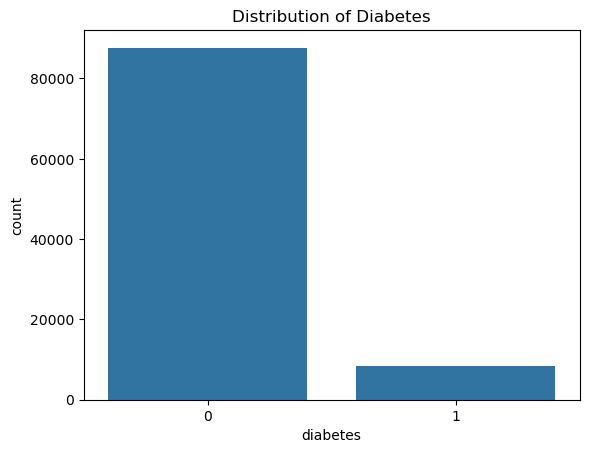

In [18]:
sns.countplot(x="diabetes", data=df)
plt.title("Distribution of Diabetes")
plt.show()

#####  0 represents patients who do not have diabetes.
#####  1 represents patients who have diabetes.
##### By comparing the heights of the bars, we can determine whether one class is much more common than the other.

## Step 10 — Separate Numerical and Categorical Features
##### Different preprocessing methods are applied to numerical and categorical features. Identifying them early makes later steps easier.

In [19]:
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(numerical_columns)

print()

print("Categorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes'],
      dtype='object')

Categorical Columns:
Index(['gender', 'smoking_history'], dtype='object')


## Step 11 — Univariate Analysis of Numerical Features
##### Numerical features help us understand the distribution of values, identify skewness, and detect unusual observations.

#### Remove Target Column

In [20]:
numerical_columns = numerical_columns.drop("diabetes")

##### Age is an important factor that may influence the likelihood of diabetes. Analyzing its distribution helps us understand the age groups represented in the dataset.

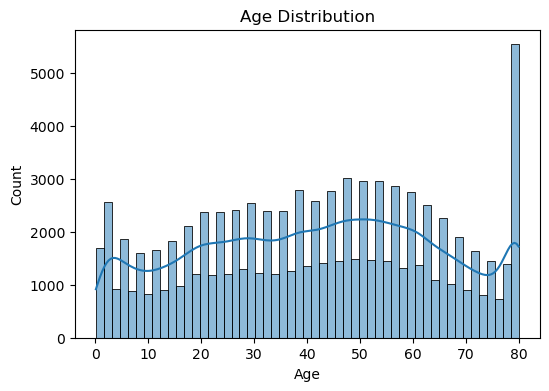

In [22]:
plt.figure(figsize=(6,4))

sns.histplot(df["age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

##### The histogram indicates that the dataset mainly consists of middle-aged adults. The number of patients gradually decreases in older age groups.

#### 2. BMI Distribution

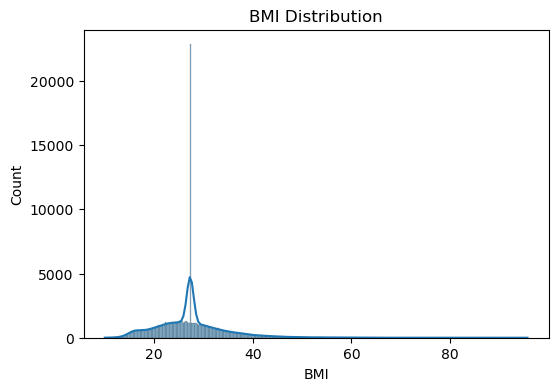

In [23]:
plt.figure(figsize=(6,4))

sns.histplot(df["bmi"], kde=True)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")

plt.show()

##### Most BMI values are between 25 and 35.

#### 3. Blood Glucose Level Distribution
##### Blood glucose level is one of the strongest indicators used to diagnose diabetes.

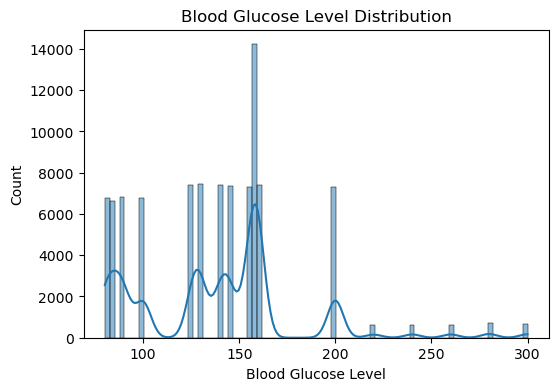

In [24]:
plt.figure(figsize=(6,4))

sns.histplot(df["blood_glucose_level"], kde=True)

plt.title("Blood Glucose Level Distribution")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Count")

plt.show()

##### Blood glucose levels are concentrated in the lower range, while only a small proportion of patients exhibit extremely high glucose levels.

#### 4 HbA1c Level Distribution
##### HbA1c measures the average blood sugar level over the previous few months and is widely used for diabetes diagnosis.

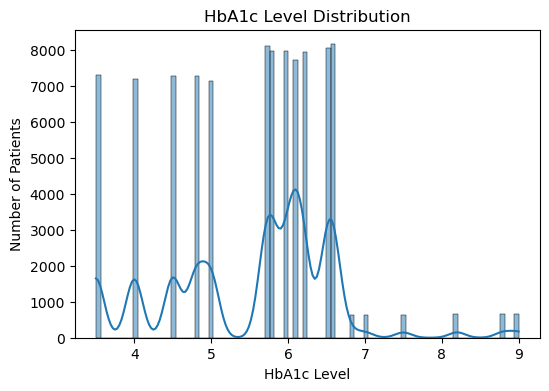

In [25]:
plt.figure(figsize=(6,4))

sns.histplot(df["HbA1c_level"], kde=True)

plt.title("HbA1c Level Distribution")
plt.xlabel("HbA1c Level")
plt.ylabel("Number of Patients")

plt.show()

##### The majority of patients have HbA1c levels within the lower range, while fewer patients show elevated values that may indicate diabetes.

#### 5 Heart Disease Distribution
##### Heart disease is also a binary feature. A count plot helps visualize the number of patients with and without heart disease.

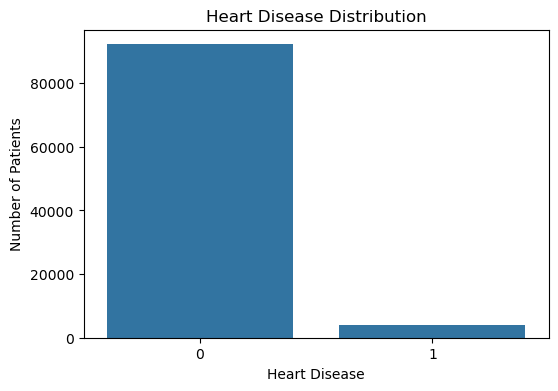

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(x="heart_disease", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.show()

##### The majority of patients in the dataset do not have heart disease, while only a small proportion have been diagnosed with it.

## Step 12 – Univariate Analysis of Categorical Features

### Gender Distribution
##### Gender may influence the occurrence of diabetes. Understanding its distribution helps us determine whether the dataset contains a balanced representation of different genders.

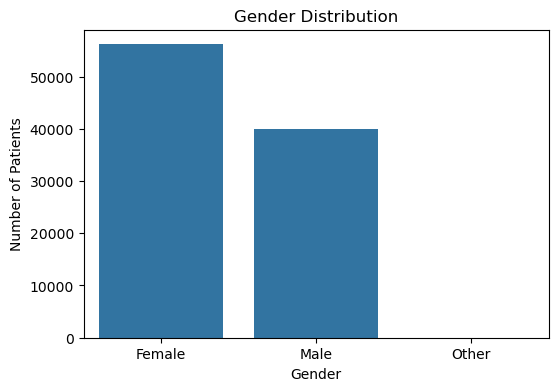

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x="gender", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

### Smoking History Distribution
##### Smoking is considered a potential risk factor for diabetes and other health conditions. Analyzing smoking history helps us understand the lifestyle characteristics of the patients.

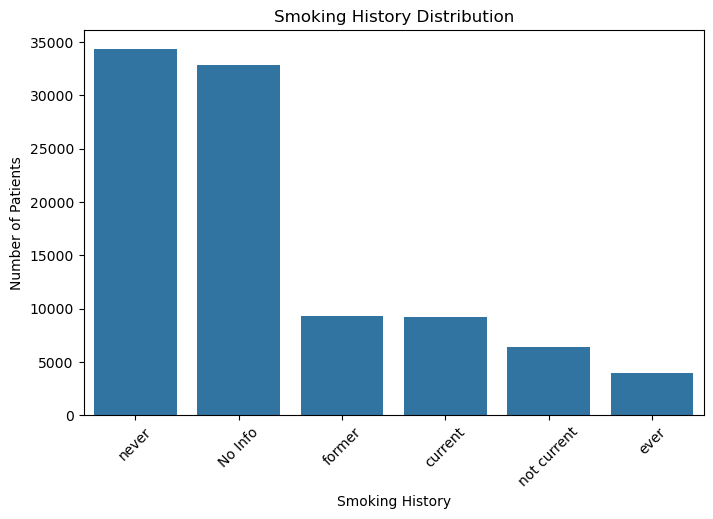

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="smoking_history",
    data=df,
    order=df["smoking_history"].value_counts().index
)

plt.title("Smoking History Distribution")
plt.xlabel("Smoking History")
plt.ylabel("Number of Patients")

plt.xticks(rotation=45)

plt.show()

##### The majority of patients have never smoked, while relatively fewer patients are current or former smokers. A considerable number of records have no available smoking history information.

## Step 13 – Bivariate Analysis
##### Bivariate analysis examines the relationship between each feature and the target variable (diabetes). This helps identify which factors are most strongly associated with diabetes.

#### 1. Age vs Diabetes
##### Age is a well-known risk factor for diabetes. This analysis helps determine whether diabetic patients tend to be older than non-diabetic patients.

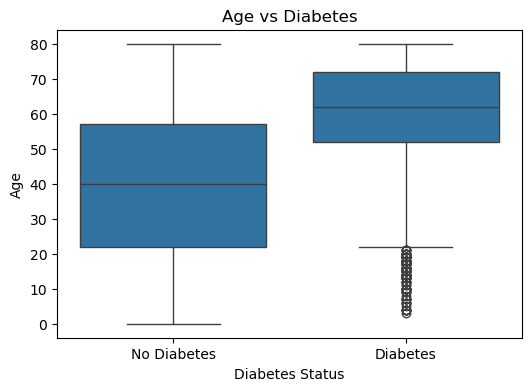

In [31]:
plt.figure(figsize=(6,4))

sns.boxplot(x="diabetes", y="age", data=df)

plt.title("Age vs Diabetes")
plt.xlabel("Diabetes Status")
plt.ylabel("Age")

# Change x-axis labels
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])

plt.show()

##### Diabetic patients generally tend to be older than non-diabetic patients, suggesting that age may influence diabetes risk.

#### 2. BMI vs Diabetes
#####  Higher BMI is often associated with obesity, which is a major risk factor for diabetes.

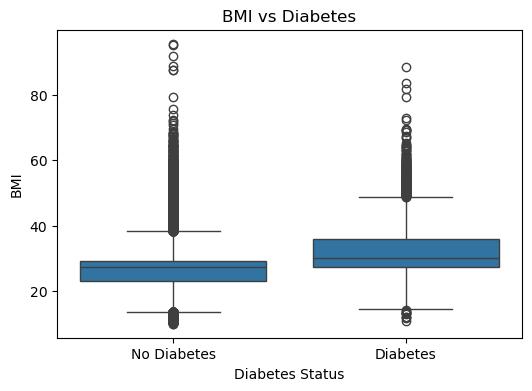

In [32]:
plt.figure(figsize=(6,4))

sns.boxplot(x="diabetes", y="bmi", data=df)

plt.title("BMI vs Diabetes")
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")

plt.xticks([0,1], ["No Diabetes","Diabetes"])

plt.show()

##### Patients with diabetes generally have a higher BMI than those without diabetes.

### 3. Blood Glucose Level vs Diabetes
##### Blood glucose level is one of the primary indicators used to diagnose diabetes.

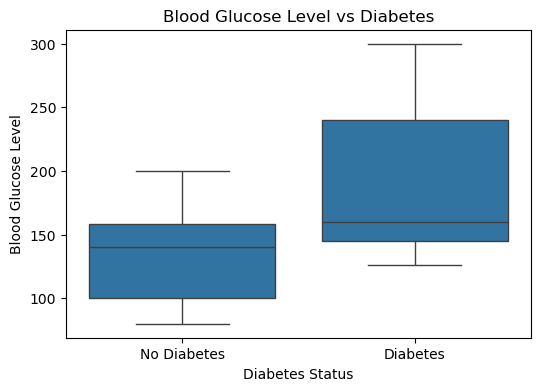

In [33]:
plt.figure(figsize=(6,4))

sns.boxplot(x="diabetes", y="blood_glucose_level", data=df)

plt.title("Blood Glucose Level vs Diabetes")
plt.xlabel("Diabetes Status")
plt.ylabel("Blood Glucose Level")

plt.xticks([0,1], ["No Diabetes","Diabetes"])

plt.show()

##### Diabetic patients have significantly higher blood glucose levels, indicating a strong relationship with diabetes.

### 4. Hypertension vs Diabetes
##### Hypertension is commonly associated with diabetes and other cardiovascular diseases. This analysis helps determine whether diabetes is more prevalent among patients with hypertension.

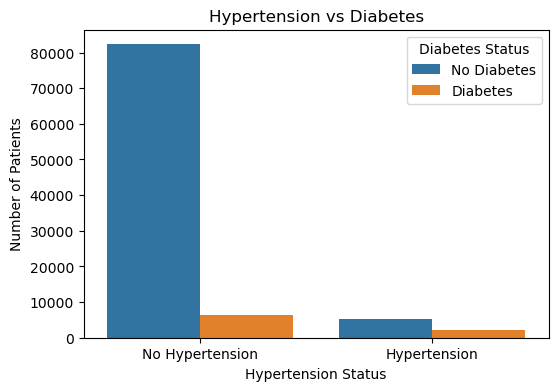

In [34]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x="hypertension", hue="diabetes", data=df)

plt.title("Hypertension vs Diabetes")
plt.xlabel("Hypertension Status")
plt.ylabel("Number of Patients")

# Rename x-axis labels
plt.xticks([0,1], ["No Hypertension","Hypertension"])

# Rename legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["No Diabetes", "Diabetes"], title="Diabetes Status")

plt.show()


##### The proportion of diabetic patients is higher among individuals with hypertension, suggesting a possible relationship between the two conditions.

## Step 15 – Correlation Analysis

##### Correlation analysis measures the strength and direction of the relationship between numerical features. It helps identify which variables are most strongly associated with the target variable (diabetes).
##### This analysis helps to:

###### Identify important features.
###### Detect highly correlated variables.
###### Gain insights into feature relationships.

#### Correlation Matrix

In [36]:

correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.257305,0.238451,0.344797,0.106719,0.114317,0.264927
hypertension,0.257305,1.000000,0.119982,0.148111,0.081441,0.084834,0.195710
heart_disease,0.238451,0.119982,1.000000,0.061376,0.068140,0.070832,0.170711
bmi,0.344797,0.148111,0.061376,1.000000,0.084423,0.092543,0.214932
HbA1c_level,0.106719,0.081441,0.068140,0.084423,1.000000,0.171615,0.406408
blood_glucose_level,0.114317,0.084834,0.070832,0.092543,0.171615,1.000000,0.424336
diabetes,0.264927,0.195710,0.170711,0.214932,0.406408,0.424336,1.000000


##### The correlation matrix provides the numerical relationship between all numerical variables and helps identify features that may influence diabetes.

#### Correlation Heatmap

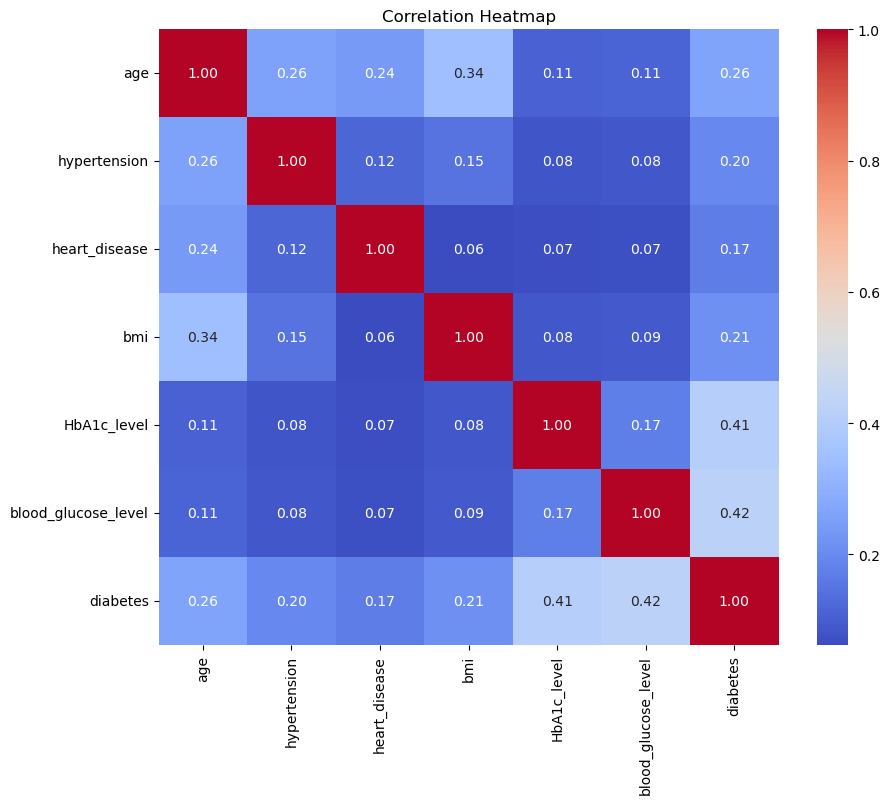

In [37]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

##### 🔴 Dark Red → Strong Positive Correlation
##### 🔵 Dark Blue → Strong Negative Correlation
##### ⚪ Light Colors → Weak or No Correlation

##### Blood glucose level and HbA1c level show the strongest positive correlation with diabetes, indicating that higher values of these features are associated with a greater likelihood of diabetes.
##### Age and BMI show a moderate positive correlation, while hypertension and heart disease have weaker positive relationships.

In [38]:
correlation_matrix["diabetes"].sort_values(ascending=False)

diabetes               1.000000
blood_glucose_level    0.424336
HbA1c_level            0.406408
age                    0.264927
bmi                    0.214932
hypertension           0.195710
heart_disease          0.170711
Name: diabetes, dtype: float64

## Step 16 – Data Preprocessing

##### Machine learning models require:

###### Features (X) → Input variables used for prediction.
###### Target (y) → Output variable that the model learns to predict.

##### In our dataset:

###### diabetes is the target variable.
###### All remaining columns are features.

In [39]:
# Features
X = df.drop("diabetes", axis=1)

# Target
y = df["diabetes"]

In [40]:
print(X.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  
0          6.6                  140  
1          6.6                   80  
2          5.7                  158  
3          5.0                  155  
4          4.8                  155  


In [41]:
print(y.head())

0    0
1    0
2    0
3    0
4    0
Name: diabetes, dtype: int64


### Identify Categorical Columns
##### Machine learning algorithms cannot directly process text values such as Male, Female, or never. Therefore, these categorical variables must be converted into numerical form.

In [42]:
X.select_dtypes(include="object").columns

Index(['gender', 'smoking_history'], dtype='object')

#### Encode Categorical Features
##### Encoding converts categorical values into numbers that machine learning algorithms can understand.

In [45]:
from sklearn.preprocessing import LabelEncoder

In [46]:
le = LabelEncoder()

In [47]:
X["gender"] = le.fit_transform(X["gender"])

In [48]:
X["smoking_history"] = le.fit_transform(X["smoking_history"])

In [49]:
X.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,0,80.0,0,1,4,25.19,6.6,140
1,0,54.0,0,0,0,27.32,6.6,80
2,1,28.0,0,0,4,27.32,5.7,158
3,0,36.0,0,0,1,23.45,5.0,155
4,1,76.0,1,1,1,20.14,4.8,155


###### The categorical features were converted into numerical values using Label Encoding, making the dataset suitable for machine learning algorithms.

##### Verify Data Types

In [50]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  int64  
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  int64  
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 6.6 MB


## Step 17: Train-Test Split

##### Before training a machine learning model, we divide the dataset into two parts:

##### Training Set → Used to train the model.
##### Testing Set → Used to evaluate the model on unseen data.

##### If we train and test the model on the same data, it may simply memorize the dataset and appear to perform well without actually learning patterns. Splitting the data provides a more realistic evaluation.

##### 80% of the data for training.
##### 20% of the data for testing.


#### Import Train-Test Split

In [51]:
from sklearn.model_selection import train_test_split

#### Split the Dataset

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

##### Verify the Split

In [53]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print()

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features: (76916, 8)
Testing Features : (19230, 8)

Training Target : (76916,)
Testing Target  : (19230,)


## Step 18 – Train the Logistic Regression Model
#### The objective of this step is to train a Logistic Regression model using the training dataset. The model will learn patterns from the input features and predict whether a patient has diabetes.

##### Logistic Regression is a supervised machine learning algorithm used for binary classification problems, where the target variable has two classes.

##### In this project:

##### 0 → No Diabetes
##### 1 → Diabetes

##### The model learns from the training data and predicts the probability that a patient belongs to one of these two classes.

#### Import the Model

In [54]:
from sklearn.linear_model import LogisticRegression

#### Create the Model

In [55]:
lr_model = LogisticRegression(max_iter=1000)

#### Train the Model

In [56]:
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


##### The Logistic Regression model was successfully trained using the training dataset. During training, the model learned the relationship between the patient features and diabetes status.

## Step 19 – Make Predictions

In [57]:
y_pred = lr_model.predict(X_test)

<!-- 
Prediction values:

Prediction	Meaning
     0	     No Diabetes
     1	     Diabetes -->

## Step 20 – Evaluate the Model

In [62]:
from sklearn.metrics import accuracy_score

#### Accuracy

In [63]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9569942797711909
